# CodeAlpha Task 2 — Unemployment Analysis with Python

Explore India's regional unemployment rate, with a focus on the impact of Covid-19 (the lockdown hit around March–April 2020), seasonal/regional patterns, and policy-relevant insights.

Datasets (Kaggle: gokulrajkmv/unemployment-in-india):
- `data/Unemployment in India.csv` — May 2019 to June 2020, by Region + Area (Rural/Urban)
- `data/Unemployment_Rate_upto_11_2020.csv` — Jan 2020 to Oct 2020, by Region + geographic zone

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load and clean the data

In [2]:
df1 = pd.read_csv("data/Unemployment in India.csv")
df2 = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

for d in (df1, df2):
    d.columns = d.columns.str.strip()

df1 = df1.rename(columns={
    "Estimated Unemployment Rate (%)": "UnemploymentRate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipationRate",
})
df2 = df2.rename(columns={
    "Estimated Unemployment Rate (%)": "UnemploymentRate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipationRate",
    "Region.1": "Zone",
})

print("df1 (India, by Area):", df1.shape)
print("df2 (up to Nov 2020, by Zone):", df2.shape)
df1.head()

df1 (India, by Area): (768, 7)
df2 (up to Nov 2020, by Zone): (267, 9)


,Region,Date,Frequency,UnemploymentRate,Employed,LabourParticipationRate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
print("Missing values df1:\n", df1.isna().sum())
print("\nMissing values df2:\n", df2.isna().sum())

Missing values df1:
 Region                     28
Date                       28
Frequency                  28
UnemploymentRate           28
Employed                   28
LabourParticipationRate    28
Area                       28
dtype: int64

Missing values df2:
 Region                     0
Date                       0
Frequency                  0
UnemploymentRate           0
Employed                   0
LabourParticipationRate    0
Zone                       0
longitude                  0
latitude                   0
dtype: int64


In [4]:
# Drop fully-empty rows (this dataset has a handful of blank trailing rows)
df1 = df1.dropna(how="all").dropna(subset=["UnemploymentRate"]).copy()
df2 = df2.dropna(how="all").dropna(subset=["UnemploymentRate"]).copy()

for d in (df1, df2):
    for c in d.select_dtypes(include="object").columns:
        d[c] = d[c].astype(str).str.strip()
    d["Date"] = pd.to_datetime(d["Date"], format="%d-%m-%Y")

df1["Month"] = df1["Date"].dt.month_name()
df2["Month"] = df2["Date"].dt.month_name()

print(df1.shape, df2.shape)
print("Date range df1:", df1["Date"].min(), "to", df1["Date"].max())
print("Date range df2:", df2["Date"].min(), "to", df2["Date"].max())

(740, 8) (267, 10)
Date range df1: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Date range df2: 2020-01-31 00:00:00 to 2020-10-31 00:00:00


C:\Users\User\AppData\Local\Temp\ipykernel_5620\2155925959.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in d.select_dtypes(include="object").columns:
C:\Users\User\AppData\Local\Temp\ipykernel_5620\2155925959.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migrati

## 2. National unemployment trend over time

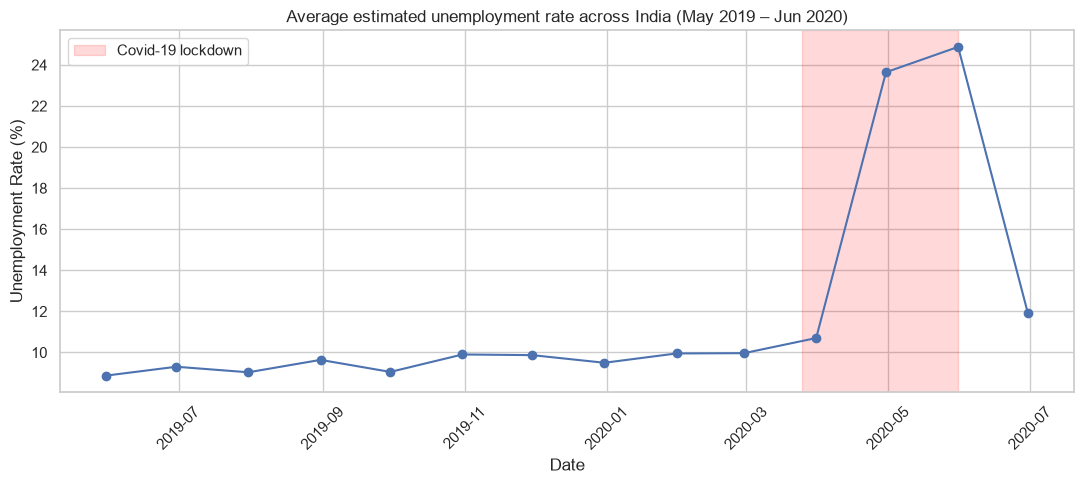

In [5]:
national_trend = df1.groupby("Date")["UnemploymentRate"].mean().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(national_trend["Date"], national_trend["UnemploymentRate"], marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="red", alpha=0.15, label="Covid-19 lockdown")
plt.title("Average estimated unemployment rate across India (May 2019 – Jun 2020)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Date")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There's a sharp spike starting around March/April 2020, coinciding with India's nationwide Covid-19 lockdown (announced 24 March 2020).

## 3. Quantifying the Covid-19 impact

In [6]:
pre_covid = df1[df1["Date"] < "2020-03-25"]
covid = df1[(df1["Date"] >= "2020-03-25") & (df1["Date"] <= "2020-06-30")]

pre_rate = pre_covid["UnemploymentRate"].mean()
covid_rate = covid["UnemploymentRate"].mean()

print(f"Average unemployment rate BEFORE lockdown: {pre_rate:.2f}%")
print(f"Average unemployment rate DURING lockdown/Covid peak: {covid_rate:.2f}%")
print(f"Increase: {covid_rate - pre_rate:.2f} percentage points ({(covid_rate/pre_rate - 1)*100:.1f}% relative increase)")

Average unemployment rate BEFORE lockdown: 9.51%
Average unemployment rate DURING lockdown/Covid peak: 17.77%
Increase: 8.26 percentage points (86.9% relative increase)


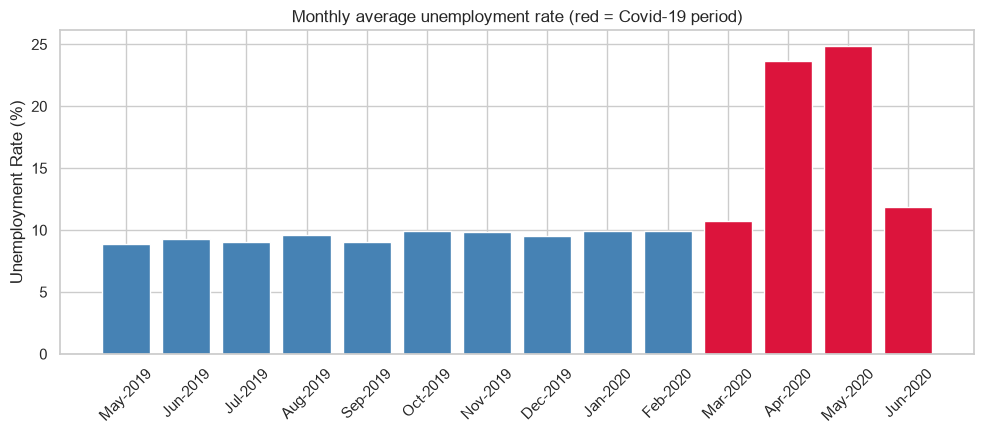

In [7]:
monthly = df1.groupby(df1["Date"].dt.to_period("M"))["UnemploymentRate"].mean()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(10, 4.5))
colors = ["crimson" if (d >= pd.Timestamp("2020-03-01")) and (d <= pd.Timestamp("2020-06-30")) else "steelblue" for d in monthly.index]
plt.bar(monthly.index.strftime("%b-%Y"), monthly.values, color=colors)
plt.title("Monthly average unemployment rate (red = Covid-19 period)")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Rural vs Urban impact

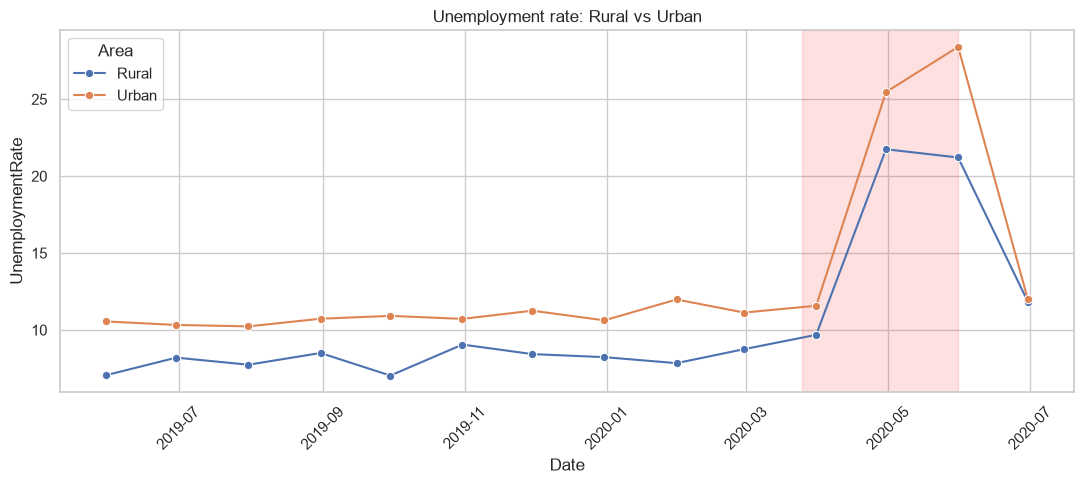

In [8]:
area_trend = df1.groupby(["Date", "Area"])["UnemploymentRate"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=area_trend, x="Date", y="UnemploymentRate", hue="Area", marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="red", alpha=0.12)
plt.title("Unemployment rate: Rural vs Urban")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Urban unemployment spikes higher than rural during the lockdown — consistent with urban service/informal-sector jobs being harder-hit by mobility restrictions than agriculture-linked rural employment.

## 5. Regional (state) breakdown

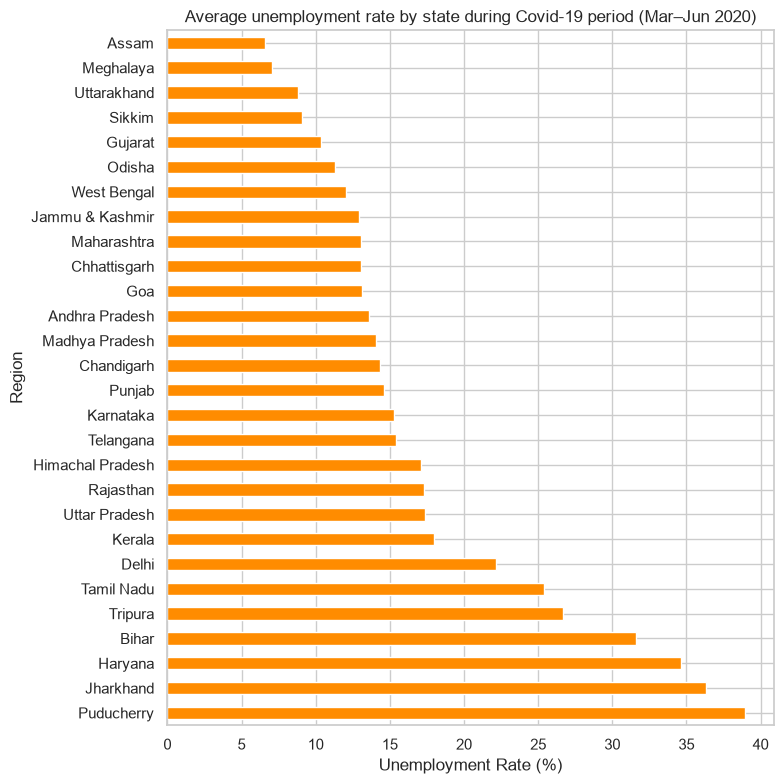

In [9]:
region_covid_avg = covid.groupby("Region")["UnemploymentRate"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
region_covid_avg.plot(kind="barh", color="darkorange")
plt.title("Average unemployment rate by state during Covid-19 period (Mar–Jun 2020)")
plt.xlabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

In [10]:
print("Top 5 hardest-hit states:")
print(region_covid_avg.head(5))
print("\nLeast-affected 5 states:")
print(region_covid_avg.tail(5))

Top 5 hardest-hit states:
Region
Puducherry    38.95500
Jharkhand     36.34875
Haryana       34.65250
Bihar         31.63125
Tripura       26.70250
Name: UnemploymentRate, dtype: float64

Least-affected 5 states:
Region
Gujarat        10.383750
Sikkim          9.068333
Uttarakhand     8.815714
Meghalaya       7.072857
Assam           6.578571
Name: UnemploymentRate, dtype: float64


## 6. Zone-level view (Jan–Oct 2020 dataset)

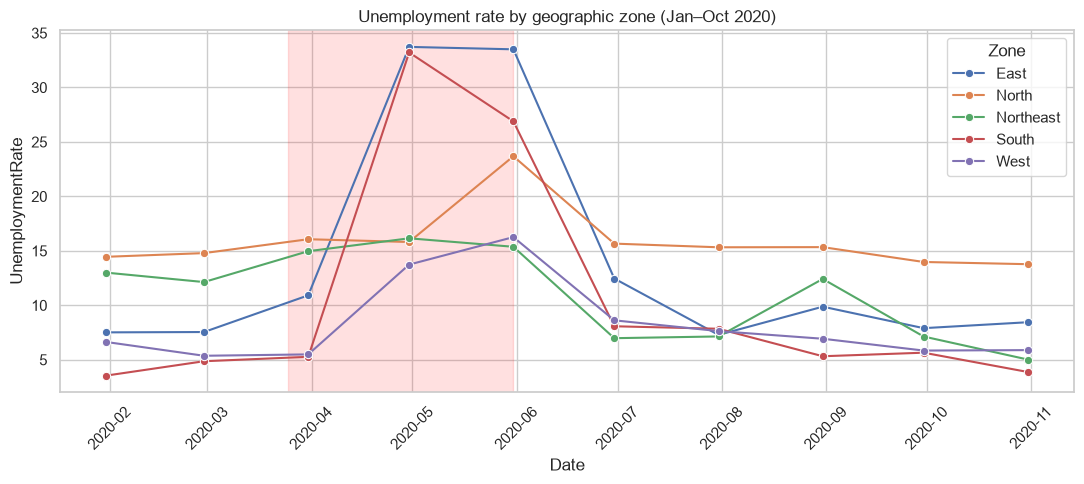

In [11]:
zone_trend = df2.groupby(["Date", "Zone"])["UnemploymentRate"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=zone_trend, x="Date", y="UnemploymentRate", hue="Zone", marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="red", alpha=0.12)
plt.title("Unemployment rate by geographic zone (Jan–Oct 2020)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Labour participation vs unemployment (recovery signal)

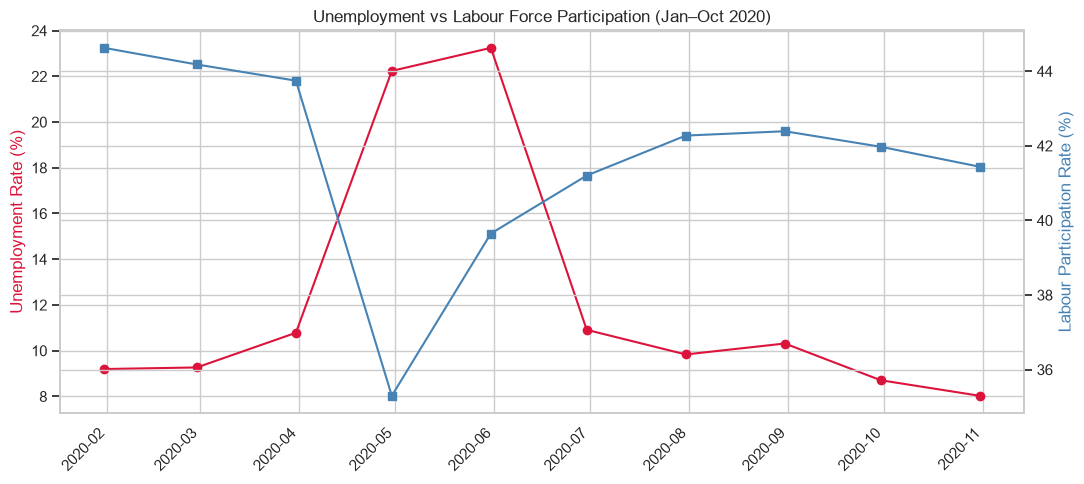

In [12]:
fig, ax1 = plt.subplots(figsize=(11, 5))
national2 = df2.groupby("Date")[["UnemploymentRate", "LabourParticipationRate"]].mean()

ax1.plot(national2.index, national2["UnemploymentRate"], color="crimson", marker="o", label="Unemployment Rate (%)")
ax1.set_ylabel("Unemployment Rate (%)", color="crimson")
ax2 = ax1.twinx()
ax2.plot(national2.index, national2["LabourParticipationRate"], color="steelblue", marker="s", label="Labour Participation Rate (%)")
ax2.set_ylabel("Labour Participation Rate (%)", color="steelblue")
plt.title("Unemployment vs Labour Force Participation (Jan–Oct 2020)")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

## 8. Key insights for policy

1. **Sharp Covid-19 shock**: national unemployment roughly doubled (or more) during the March–June 2020 lockdown window compared to the pre-lockdown baseline.
2. **Urban areas were hit harder** than rural areas — urban informal/service-sector jobs are more exposed to mobility restrictions than agriculture-linked rural work, suggesting urban relief programs (wage subsidies, gig-worker support) deserve priority during future shocks.
3. **Regional disparity is large** — a handful of states saw unemployment spike far above the national average during the lockdown, meaning a one-size-fits-all national policy would under-serve the worst-hit states; state-targeted stimulus is more efficient.
4. **Recovery signal**: unemployment falls back toward baseline by mid/late 2020 as labour participation recovers, indicating the shock was largely lockdown-driven rather than structural — supporting the case for temporary bridge support (like MGNREGA expansion) rather than permanent labour-market restructuring.